# Task 1: Download and Visualize Sentinel 2 Data

In this task we focus on the municipality of **São Félix do Xingu** in the eastern sector of the Pará state in Brazil. The goal is to retrieve two Sentinel 2 tiles from the Copernicus AWS archive for two dates separated by a period of reported forest loss. Afterwards, you will visualize and qualitatively analyze these tiles.

## 1.0 Optional Step: Global Forest Watch Data Review

Before working with spectral data we can consult Global Forest Watch for annual forest cover change statistics in São Félix do Xingu.
Please look at the [Global Forest Watch map for São Félix do Xingu, Brazil](https://gfw.global/3H8Uut5) and evaluate the forst loss in the region.


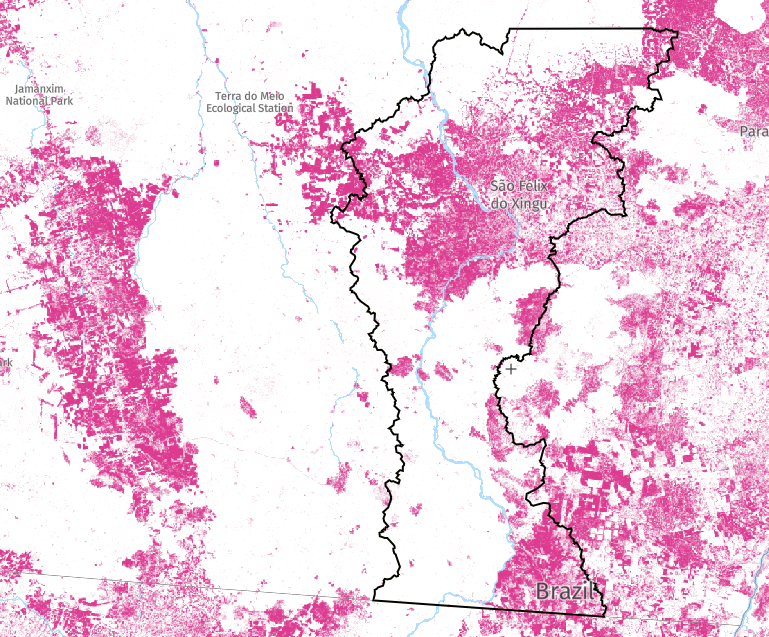


According to [Global Forest Watch](https://gfw.global/3FKpuzl), São Félix do Xingu experienced a loss of 2.15 million hectares of tree cover between 2001 and 2024, which is about a 27 percent decrease. In the more recent period from 2018 to 2024 the municipality lost 794 thousand hectares of tree cover equivalent to a 10 percent decrease in tree cover and 345 million tonnes of carbon dioxide equivalent emissions. 
To align our satellite imagery analysis with both the magnitude of recent forest loss and the availability of high quality Sentinel 2 acquisitions we focus on the years 2018 and 2024. 

###  Contextual and Seasonal Considerations

To interpret these forest-cover statistics we must consider the principal land-use drivers in São Félix do Xingu; cattle ranching expansion and commercial agriculture have accelerated canopy removal in recent years, and infrastructure development such as logging roads fragment contiguous forest blocks.

Furthermore we must account for seasonal and atmospheric factors when selecting our two dates; the dry season in this region, roughly July through September, offers the clearest skies for optical imagery whereas the wet season introduces increased cloud cover and potential [sun-glint](https://www.euspaceimaging.com/blog/2023/12/18/how-eusi-avoids-sun-glint-in-satellite-images/) off wet leaves. 

## 1.1 Accessing Earth Observation Data via Copernicus Data Space S3

To download Sentinel-2 products from Copernicus Data Space via S3 you must first register for the Data Space service by creating a Copernicus user account. Once authenticated you can generate S3 credentials comprising an access key ID and a secret access key (see [Copernicus Data Space S3 API documentation](https://documentation.dataspace.copernicus.eu/APIs/S3.html)). Store these credentials securely in a `.env` file at the project root so that they can be loaded at runtime without exposing sensitive information.

### Detailed Task description
1. Register and obtain S3 credentials from Copernicus Data Space, store your access key ID and secret access key in a `.env` file.
   (Note: Please do not upload this file for the submission. We will use our own .env file)


### Imports
These are all imports we used when solving the task. Please leave them as is even though you might not need all of them.

In [1]:
import os
import rootutils
root = rootutils.setup_root(os.path.abspath(''), dotenv=True, pythonpath=True, cwd=False)

data_path = root / "data"
data_path.mkdir(exist_ok=True)
output_dir = root / "output"
output_dir.mkdir(exist_ok=True)


In [2]:
from datetime import date
from pathlib import Path
from typing import Optional, Iterable, Tuple

import boto3
import numpy as np
import osmnx as ox
import pandas as pd
import requests
from dotenv import load_dotenv
from collections import defaultdict
import geopandas as gpd
from shapely.geometry import Polygon


pd.set_option('display.max_columns', None)  
pd.set_option('display.max_colwidth', None) 

DESIRED_BANDS =['B02_10m', 'B03_10m', 'B04_10m', 'B08_10m',
               'B05_20m', 'B06_20m', 'B07_20m', 'B8A_20m',
               'B11_20m', 'B12_20m']

load_dotenv()  # defaults to loading .env from current dir

access_key = os.getenv("AWS_ACCESS_KEY_ID")
secret_key = os.getenv("AWS_SECRET_ACCESS_KEY")

## 1.2 Querying the Copernicus OData API for Sentinel-2 Data

In this step, you will identify and retrieve Sentinel-2 Level 2A (L2A) imagery for São Félix do Xingu for two specific dry season periods. The goal is to obtain comparable data from both 2018 and 2024 for subsequent analysis.

**Note:** Sentinel-2 L2A products are atmospherically corrected surface reflectance data, processed from Level 1C using the Sen2Cor processor. For detailed information on these products, refer to the [Sentinel-2 L2A documentation](https://docs.sentinel-hub.com/api/latest/data/sentinel-2-l2a).

### Detailed Task description

1. Query the Copernicus OData API to retrieve Sentinel-2 Level 2A products satisfying the following constraints for both 2018 and 2024:

- **Area of interest:** Full envelope of São Félix do Xingu
- **Acquisition dates:** Between 20 July and 30 July  
- **Cloud cover:** Maximum of 0.5%  
- **Product type:** Level 2A (atmospherically corrected products)  
- **Spatial consistency:** Retain only those Sentinel-2 tiles that are present in both years (based on tile name)
- **Most recent tile:** ...

   You can use the function `dataspace_dataframe_from_attributes` to obtain the dataframe (see Lab01).

2. Convert both resulting DataFrames into GeoDataFrames using the available spatial metadata. Visualize them with the `explore()` method to verify whether the selected tiles overlap spatially.


In [3]:
# Query dataframe from Copernicus API (code taken from Lab01)
def dataspace_dataframe_from_attributes(
    collection: str = "SENTINEL-2",
    aoi: Optional[str] = None,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
    attributes: Optional[Iterable[Tuple[str, str, float]]] = None,
    max_returned_items: int = 20
):
    """
    Get a dataframe of items from the Copernicus DataSpace API based on the given attributes.
    The request is build based on the OData standard as documented at
    https://documentation.dataspace.copernicus.eu/APIs/OData.html

    Parameters
    ----------
    collection : str
        The collection to search for. Default is "SENTINEL-2".
    aoi : str, optional
        The area of interest in WKT format. Default is None.
    start_date : str, optional
        The start date in the format "YYYY-MM-DD". Default is None.
    end_date : str, optional
        The end date in the format "YYYY-MM-DD". Default is None.
    attributes : Iterable[Tuple[str, str, float]], optional
        The attributes to filter by. Default is None which means no filtering and is equivalent to an empty list.
        Each tuple should be in the format (key, comparison, value).
        The comparison should be one of "lt", "le", "eq", "ge", "gt".
        Currently only attributes of type double and that are comparable are supported.
    max_returned_items : int, optional
        The maximum number of items to return. Default is 20. Must be in [0, 1000].
    """
    if attributes is None:
        attributes = []
    request_str = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter="
    request_str += f"Collection/Name eq '{collection}'"
    if aoi is not None:
        request_str += f" and OData.CSC.Intersects(area=geography'SRID=4326;{aoi}')"
    if start_date is not None:
        request_str += f" and ContentDate/Start gt {start_date}T00:00:00.000Z"
    if end_date is not None:
        request_str += f" and ContentDate/Start lt {end_date}T00:00:00.000Z"
    for k, comp, v in attributes:
        assert comp in ["lt", "le", "eq", "ge", "gt"]
        #request_str += f" and Attributes/OData.CSC.DoubleAttribute/any(att:att/Name eq '{k}' and att/OData.CSC.DoubleAttribute/Value {comp} {v:.2f})"
        if isinstance(v, (int, float)):
            request_str += f" and Attributes/OData.CSC.DoubleAttribute/any(att:att/Name eq '{k}' and att/OData.CSC.DoubleAttribute/Value {comp} {v:.2f})"
        elif isinstance(v, str):
            request_str += f" and Attributes/OData.CSC.StringAttribute/any(att:att/Name eq '{k}' and att/OData.CSC.StringAttribute/Value {comp} '{v}')"
            
    # get all attributes
    request_str += "&$expand=Attributes"
    # get top n items
    assert 0 <= max_returned_items <= 1000, f"Copernicus API only allows returned items in [0, 1000], but {max_returned_items} is outside this range."
    request_str += f"&$top={max_returned_items}"
    json_result = requests.get(request_str).json()
    json_vals = json_result['value']
    return pd.DataFrame.from_dict(json_result['value'])

In [4]:
# Get dataframe of products from 2018 and 2024 respectively

# Area of interest
aoi = f"{ox.geocode_to_gdf(" São Félix do Xingu").envelope.geometry[0]}"

products_2018 = dataspace_dataframe_from_attributes(
    aoi=aoi,
    start_date=date(year=2018, month=7, day=20).strftime("%Y-%m-%d"),
    end_date=date(year=2018, month=7, day=30).strftime("%Y-%m-%d"),
    attributes=[('cloudCover', 'le', 0.5), ("productType", "eq", "S2MSI2A")], # L2A products
    max_returned_items=1000,
)
products_2024 = dataspace_dataframe_from_attributes(
    aoi=aoi,
    start_date=date(year=2024, month=7, day=20).strftime("%Y-%m-%d"),
    end_date=date(year=2024, month=7, day=30).strftime("%Y-%m-%d"),
    attributes=[('cloudCover', 'le', 0.5), ("productType", "eq", "S2MSI2A")], # L2A products
    max_returned_items=1000,
)

print(f"Number of products from 2018: {len(products_2018)}")
print(f"Number of products from 2024: {len(products_2024)}")

Number of products from 2018: 61
Number of products from 2024: 53


In [5]:
# Helper functions
def extract_acquisition_date(name):
    substrings = name.split("_")
    date_time = substrings[2][:8]
    return date(year=int(date_time[:4]), month=int(date_time[4:6]), day=int(date_time[6:8]))
def extract_tile_name(name):
    substrings = name.split("_")
    return substrings[5]

# Keep only most recent product for each tile from 2018/2024
print("Keep only most recent product for each tile...")

products_2018["acquisition_date"] = products_2018["Name"].apply(extract_acquisition_date)
products_2018["tile_name"] = products_2018["Name"].apply(extract_tile_name)
products_2018 = products_2018.sort_values(by=["acquisition_date"], ascending=False)
products_2018 = products_2018.drop_duplicates(subset=["tile_name"], keep="first")

products_2024["acquisition_date"] = products_2024["Name"].apply(extract_acquisition_date)
products_2024["tile_name"] = products_2024["Name"].apply(extract_tile_name)
products_2024 = products_2024.sort_values(by=["acquisition_date"], ascending=False)
products_2024 = products_2024.drop_duplicates(subset=["tile_name"], keep="first")

print(f"Number of products from 2018: {len(products_2018)}")
print(f"Number of products from 2024: {len(products_2024)}")

# Keep only products that are present in both years
print("Keep only products that are present in both years...")

products_2018 = products_2018[products_2018["tile_name"].isin(products_2024["tile_name"])]
products_2024 = products_2024[products_2024["tile_name"].isin(products_2018["tile_name"])]

print(f"Number of products from 2018: {len(products_2018)}")
print(f"Number of products from 2024: {len(products_2024)}")

Keep only most recent product for each tile...
Number of products from 2018: 26
Number of products from 2024: 28
Keep only products that are present in both years...
Number of products from 2018: 25
Number of products from 2024: 25


In [6]:
# Convert DataFrame into GeoDataFrame (code taken from Lab01)
def copernicus_df_to_gdf(copernicus_df: pd.DataFrame, strftime: Optional[str] = None) -> gpd.GeoDataFrame:
    if strftime is not None and strftime.lower() in ['iso', 'iso 8601', 'default']:
        strftime = '%Y-%m-%dT%H:%M:%S'
    df = copernicus_df.copy()
    # split footprint into geometry (wkt text) and crs
    # assign crs
    crss = df['Footprint'].apply(lambda x: "EPSG:"+x.split(';')[0].split("'")[1].split('=')[1])
    assert len(crss.unique()) == 1, "Multiple CRS values in data frame, geopandas can't handle that."
    # assign geometry
    df['geometry'] = gpd.GeoSeries.from_wkt(df['Footprint'].apply(lambda x: x.split(';')[1].split("'")[0]), crs=crss.iloc[0])
    gdf = gpd.GeoDataFrame(df)
    attribute_names = set(sl['Name'] for l in gdf['Attributes'] for sl in l)
    ignored_date_conversions = []
    successful_date_conversions = []
    for attr in attribute_names:
        gdf[attr] = gdf['Attributes'].apply(lambda x: [i for i in x if i['Name'] == attr][0]['Value'] if len([i for i in x if i['Name'] == attr]) > 0 else np.nan)
    for attr in gdf.columns:
        if 'Date' in attr:
            # convert to DateTime
            try:
                gdf[attr] = pd.to_datetime(gdf[attr], yearfirst=True, format='mixed')
                # convert to numeric or string to make it json-serializable
                if strftime is None:
                    gdf[attr] = gdf[attr].values.astype(np.int64) // 10 ** 9
                else:
                    gdf[attr] = gdf[attr].dt.strftime(strftime)
            except Exception as e:
                ignored_date_conversions += [attr]
                continue
            successful_date_conversions += [attr]
    print(f"Ignored date conversions: {ignored_date_conversions}")
    print(f"Successful date conversions: {successful_date_conversions}")
    return gdf
    
gdf_2018 = copernicus_df_to_gdf(products_2018, strftime='ISO')
gdf_2018.explore()

Ignored date conversions: ['EvictionDate', 'ContentDate']
Successful date conversions: ['OriginDate', 'PublicationDate', 'ModificationDate', 'beginningDateTime', 'processingDate', 'endingDateTime']


In [7]:
gdf_2024 = copernicus_df_to_gdf(products_2024, strftime='ISO')
gdf_2024.explore()

Ignored date conversions: ['EvictionDate', 'ContentDate', 'sourceProductOriginDate']
Successful date conversions: ['OriginDate', 'PublicationDate', 'ModificationDate', 'processingDate', 'beginningDateTime', 'endingDateTime']


**TODO:** Describe the results in a few paragraphs.

First, we use the dataspace_dataframe_from_attributes() function from Lab01 to obtain the products from 2018 and 2024 as DataFrame objects. As product type, we specify "S2MSI2A" to query L2A products (Page 54/487 of [Sentinel-2 Products Specification Document](https://sentiwiki.copernicus.eu/__attachments/1692737/S2-PDGS-CS-DI-PSD%20-%20S2%20Product%20Specification%20Document%202024%20-%2015.0.pdf?inst-v=4ece9b51-c9c2-42f6-96f6-479e12c9d659)). From 2018, we receive 61 products, whereas from 2024, we get 53.

After receiving the data, we retain the most recent product of each tile. We add the columns "acquisition_date" and "tile_name" to sort the products by their acquisition time and to save only the latest one for each tile name. The entries of both columns are derived by the product's names as these names are obliged to a name convention stated in the [Product Overview](https://sentiwiki.copernicus.eu/web/s2-products) of Sentinel-2. This reduces the number of products from 2018 and 2024 to 26 and 28, so roughly half of the data, which makes sense since Sentinel-2  revisits the same area every 5 days and we use an acquisition window of 10 days.

Then, we only keep those products that are present in both years such that we only have 25 tiles in both DataFrames. With the copernicus_df_to_gdf() function from Lab01, both DataFrames are converted into GeoDataFrames. Using that, we can see that only a few tiles overlap fully between the two datasets, e.g. T22MCU, T22MCT and T22MCS. Moreover, some tiles also cover regions beyond São Félix do Xingu.

## 1.3 Downloading and Visualizing Sentinel-2 Tile T22MCU

Based on the results of the previous step, we now narrow our analysis to a single tile. According to Global Forest Watch and our tile inspection using the GeoDataFrame, tile **T22MCU** lies in the northern sector of São Félix do Xingu, an area that has experienced significant deforestation between 2018 and 2024. The tile shows complete data coverage and spatially aligns with settlement and agricultural zones, making it a suitable candidate for further analysis.

The goal in this step is to programmatically download selected bands from the Sentinel-2 Level 2A products for tile T22MCU for both 2018 and 2024 and to visualize the corresponding RGB composites. 

To minimize storage overhead, restrict the download to bands that are required for classification tasks compatible with the [BigEarthNet v2](https://arxiv.org/abs/1902.06148) label set. You can use the AWS S3 API (via `boto3`) for efficient access. Refer to the same [Copernicus Data Space S3 API documentation](https://documentation.dataspace.copernicus.eu/APIs/S3.html) for endpoint configuration and signing instructions.

### Detailed Task Description

1. **Tile Selection**  
   From the GeoDataFrame constructed in Task 1.2, filter the entries to retain only those with `tileName == 'T22MCU'`. Confirm that exactly one product is retained for each of the two target years (2018 and 2024).

2. **Band Selection and Download via `boto3`**  
   Use the AWS SDK for Python (`boto3`) to authenticate with the Copernicus Data Space S3 endpoint using credentials stored in the `.env` file.  
   For each of the two selected products:
   - Access the product path from the S3 URL in the dataframe.
   - Retrieve only the following bands, organizing them into subfolders, respectively:

     ```
     DESIRED_BANDS = [
         'B02_10m', 'B03_10m', 'B04_10m', 'B08_10m',
         'B05_20m', 'B06_20m', 'B07_20m', 'B8A_20m',
         'B11_20m', 'B12_20m'
     ]
     ```

3. **RGB Composite Visualization**  
   For each year:
   - Stack bands `B04_10m` (red), `B03_10m` (green), and `B02_10m` (blue) (in this order!) into a 3-channel array.
   - Normalize the image, e.g. Quantile Based Normalization, and plot it.

4. **Interpretation**  
   Briefly describe in 2-3 paragraphs the visual differences between the two images. Comment on land cover, visible clearings, vegetation patterns, any atmospheric artifacts such as haze or clouds, and whatever else you notice.




In [8]:
# 1. Tile selection
tile_2018 = products_2018.loc[products_2018["tile_name"] == "T22MCU"]
tile_2024 = products_2024.loc[products_2024["tile_name"] == "T22MCU"]

len_2018, len_2024 = len(tile_2018), len(tile_2024)
assert len_2018 == 1, f"Exactly 1 tile named \"T22MCU\" must exist, but {len_2018} exists"
assert len_2024 == 1, f"Exactly 1 tile named \"T22MCU\" must exist, but {len_2024} exists"

In [9]:
# 2. Band Selection and Download (code mainly taken from https://documentation.dataspace.copernicus.eu/APIs/S3.html)
session = boto3.session.Session()
s3 = boto3.resource(
    's3',
    endpoint_url='https://eodata.dataspace.copernicus.eu',
    aws_access_key_id=access_key,
    aws_secret_access_key=secret_key,
    region_name='default'
)  # generated secrets

def download(bucket, product: str, target: str = "") -> None:
    """
    Downloads every file in bucket with provided product as prefix

    Raises FileNotFoundError if the product was not found

    Args:
        bucket: boto3 Resource bucket object
        product: Path to product
        target: Local catalog for downloaded files. Should end with an `/`. Default current directory.
    """
    files = bucket.objects.filter(Prefix=product)
    if not list(files):
        raise FileNotFoundError(f"Could not find any files for {product}")
    for file in files:
        contains_band_name = [b in file.key for b in DESIRED_BANDS] # only looking for files that have a desired band in its name
        if any(contains_band_name):
            os.makedirs(os.path.dirname(file.key), exist_ok=True)
            if not os.path.isdir(file.key):
                bucket.download_file(file.key, f"{target}{file.key}")

# Download products
s3path_2018 = str(tile_2018["S3Path"]).split("eodata")[1].split("\n")[0].lstrip("13/").strip()
download(s3.Bucket("eodata"), s3path_2018)
s3path_2024 = str(tile_2024["S3Path"]).split("eodata")[1].split("\n")[0].lstrip("13/").strip()
download(s3.Bucket("eodata"), s3path_2024)

In [10]:
# 3.1 RGB Composite Visualization (code taken from Lab01)
import rasterio

def read_s2_jp2_data_with_clipping(
    band_data_path: Path, clip_geoseries: gpd.GeoSeries, envelope: bool = True
) -> np.ndarray:
    """
    Given the `band_data_path` to a JP2000 encoded GeoTIFF file, return those parts that are overlapping with the
    `clip_geoseries` GeoSeries. By default, the bounding box (`envelope`) of the geometry will be used to define the
    region of interest.
    """
    # open the GeoTIFF file which also contains the CRS metadata
    with rasterio.open(band_data_path) as data:
        # ensure that the data is using the same coordinate reference system and reproject if they don't
        reprojected_geoseries = clip_geoseries.to_crs(data.crs)
        # use the bounding box if `envelope` is set => Make sure that the matrix we get back can contain
        # only valid values
        reprojected_geoseries = (
            reprojected_geoseries.envelope if envelope else reprojected_geoseries
        )
        # Use crop to only return the matrix that contains our region of interest
        # Use `all_touched=True` to make sure that the border is also conisdered "inside" the region of interest
        out_img, _out_transform = rasterio.mask.mask(
            data, reprojected_geoseries, crop=True, all_touched=True
        )
        # drop singleton axes
        out_img = out_img.squeeze()
    return out_img

class S2TileReader:
    def __init__(self, directory: Path):
        """
        Initialize the reader with a directory containing the SAFE file of a Sentinel-2 product.

        Parameters
        ----------
        directory : Path
            The directory containing the SAFE file of a Sentinel-2 product.
        """
        assert directory.is_dir(), f"{directory} is not a directory"
        self.image_files = list(directory.glob(f"**/IMG_DATA/*.jp2"))
        if len(self.image_files) == 0:
            self.image_files = list(directory.glob(f"**/IMG_DATA/R60m/*.jp2"))
            self.image_files.extend(list(directory.glob(f"**/IMG_DATA/R20m/*.jp2")))
            self.image_files.extend(list(directory.glob(f"**/IMG_DATA/R10m/*.jp2")))
        self.band2file_mapping = self._bands()
        self.bands = sorted(self.band2file_mapping.keys())
        print(f"{len(self.band2file_mapping)} images found in {directory}")

    def _bands(self):
        """
        Extract the band names from the image files and create a mapping from band name to file path.

        Example:
        {
            "B01": Path("path/to/B01.jp2"),
            "B02": Path("path/to/B02.jp2"),
            ...
        }
        or if the product has multiple resolutions:
        {
            "B01_60m": Path("path/to/R60m/B01.jp2"),
            "B02_10m": Path("path/to/R10m/B02.jp2"),
            ...
        }
        """
        return {"_".join(x.stem.split("_")[2:]):x for x in self.image_files}

    def read_band(self, band: str):
        """
        Read the data of a specific band. The data is returned as a numpy array. If the band is a single channel,
        the array will have shape (height, width). If the band is a multi-channel band, the array will have shape
        (height, width, channels).

        Parameters
        ----------
        band : str
            The name of the band to read. Must be one of the bands in the product.
            Use the `bands` attribute to see the available bands.
        """
        assert band in self.bands, f"Band {band} invalid. Please select one of {self.bands}"
        img_path = self.band2file_mapping[band]
        with rasterio.open(self.band2file_mapping[band]) as f:
        #with open(self.band2file_mapping[band], 'rb') as f:
            data = f.read()
            #buffer = f.read()
            #data = np.frombuffer(buffer, dtype=np.uint8)
            #data = np.load(f)
        if data.shape[0] == 1:
            return data.squeeze(0)
        elif data.shape[0] == 3:
            return np.transpose(data, (1, 2, 0))

    def read_band_data_with_clipping(
        self, band: str, clip_geoseries: gpd.GeoSeries, envelope: bool = True
    ) -> np.ndarray:
        assert band in self.bands, f"Band {band} invalid. Please select one of {self.bands}"
        img_path = self.band2file_mapping[band]
        return read_s2_jp2_data_with_clipping(img_path, clip_geoseries, envelope=envelope)



# Convert each tile from jp2 into numpy array
dir_2018 = Path("./Sentinel-2/MSI/L2A_N0500/2018/07/23/S2B_MSIL2A_20180723T135109_N0500_R024_T22MCU_20230628T084231.SAFE")
s2_reader = S2TileReader(dir_2018)
s2_reader.bands
image_2018 = np.stack(
    [s2_reader.read_band(b) for b in ("B04_10m", "B03_10m", "B02_10m")],
    axis=-1,
)
dir_2024 = Path("./Sentinel-2/MSI/L2A/2024/07/21/S2B_MSIL2A_20240721T134709_N0510_R024_T22MCU_20240721T160820.SAFE")
s2_reader = S2TileReader(dir_2024)
s2_reader.bands
image_2024 = np.stack(
    [s2_reader.read_band(b) for b in ("B04_10m", "B03_10m", "B02_10m")],
    axis=-1,
)

# Downsampling (keep every 2nd pixel) since my kernel always keeps dying
image_2018 = image_2018[::2, ::2, :]
image_2024 = image_2024[::2, ::2, :]

10 images found in Sentinel-2/MSI/L2A_N0500/2018/07/23/S2B_MSIL2A_20180723T135109_N0500_R024_T22MCU_20230628T084231.SAFE
10 images found in Sentinel-2/MSI/L2A/2024/07/21/S2B_MSIL2A_20240721T134709_N0510_R024_T22MCU_20240721T160820.SAFE


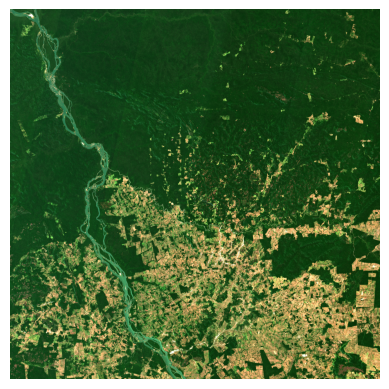

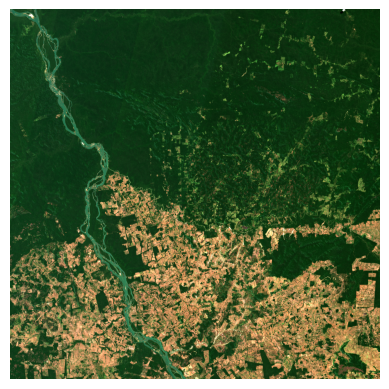

In [11]:
# 3.2 Normalization & Visualization (code taken from Lab01)
import matplotlib.pyplot as plt

def quant_norm_data(
        data: np.ndarray, lower_quant: float = 0.01, upper_quant: float = 0.99
) -> np.ndarray:
    """
    Normalize the data by quantiles `lower_quant/upper_quant`.
    The quantiles are calculated globally/*across all channels*.

    Parameters
    ----------
    data : np.ndarray
        The data to normalize.
    lower_quant : float
        The lower quantile. Default is 0.01.
    upper_quant : float
        The upper quantile. Default is 0.99.
    """
    masked_data = np.ma.masked_equal(data, 0)
    lq, uq = np.quantile(masked_data.compressed(), (lower_quant, upper_quant))
    data = np.clip(data, a_min=lq, a_max=uq)
    data = (data - lq) / (uq - lq)
    return data


def vis(data: np.ndarray, quant_norm: bool = False):
    """
    Visualize an array by calling `imshow` with `cmap="gray"` for 1 channel inputs and no cmap for 3 channel inputs.
    Expected shape is either (H, W) or (H, W, 3) for 1 and 3 channel inputs respectively. Assumes RGB order for 3
    channel inputs.

    Parameters
    ----------
    data : np.ndarray
        The data to visualize. Expected shape is either (H, W) or (H, W, 3) for 1 and 3 channel inputs respectively.
        Assumes RGB order for 3 channel inputs.
    quant_norm : bool
        Whether to quantile normalize the data. Default is False.
    """
    if quant_norm:
        data = quant_norm_data(data)
    if data.ndim == 2:
        plt.imshow(data, cmap="gray")
    elif data.ndim == 3:
        plt.imshow(data)
    else:
        raise ValueError(f"Expected data to have 2 or 3 dimensions, but got {data.ndim} dimensions.")
    plt.axis("off")
    plt.show()

vis(image_2018, quant_norm=True)
vis(image_2024, quant_norm=True)

**TODO:** Describe the results in a few paragraphs.

**4. Interpretation**

The first image is from 2018, the second from 2024. If we assume that the brown/beige pixels are bare ground, we can see that deforestation was carried out in recent years as the 2024 image contains more intense beige tones and fewer light green pixels around the bare areas compared to the 2018 one.